In [2]:
import numpy as np
import matplotlib.pyplot as plt

slope = [-1.], intercept = [3.]
4.0
The SSE for the quadratic regression eqn is 1.366701518295403e-28
The SSE for the cubic regression eqn is 1.411193273349868e-26


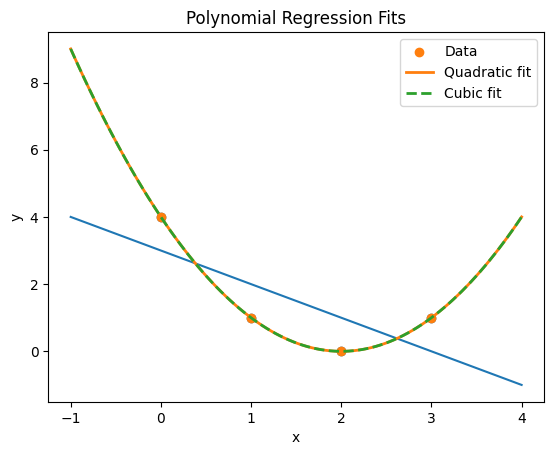

In [3]:
## =========================
## Problem
## =========================
# We are given a set of data points and want to fit models
# (linear, quadratic, cubic) using least squares.

## =========================
## Mathematical Idea
## =========================
# Least squares minimizes the sum of squared errors between
# the model predictions and observed data.

## =========================
## Data
## =========================
x = np.array([[0],[1],[2],[3]]) #initialize x column of toy data
y = np.array([[4],[1],[0],[1]]) #initialize y column of toy data


## =========================
## Linear Model
## =========================

# Create matrix A
A = np.hstack([np.ones(x.shape), x])

# Create pseudo-inverse
ATA = np.matmul(A.T,A)
ATAinv = np.linalg.inv(ATA)
pseudoInv = np.matmul(ATAinv,A.T)

# Solve for beta
beta = np.matmul(pseudoInv,y)

# Best-fit values
C,D = beta
print(f"slope = {D}, intercept = {C}")

# Model predictions
model = np.matmul(A,beta)

# Residuals
residuals = model - y

# SSE
SSE = np.squeeze(np.matmul(residuals.T,residuals))
print(SSE)


## =========================
## Plot Linear Fit
## =========================
xVec = np.linspace(-1,4,100)
yVec = D*xVec + C

plt.plot(xVec,yVec)
plt.scatter(x,y)

plt.xlabel("$x$")
plt.ylabel("$y$")


## =========================
## Quadratic Model
## =========================

# Create matrix A
A = np.hstack([np.ones(x.shape), x, x**2])

# Create pseudo-inverse
ATA = np.matmul(A.T,A)
ATAinv = np.linalg.inv(ATA)
pseudoInvA = np.matmul(ATAinv,A.T)

# Solve for beta
beta2A = np.matmul(pseudoInvA,y)

# Best-fit values
C_1, D_1, E_1 = beta2A


## =========================
## Cubic Model
## =========================

# Create matrix B
B = np.hstack([np.ones(x.shape), x, x**2, x**3])

# Create pseudo-inverse
BTB = np.matmul(B.T,B)
BTBinv = np.linalg.inv(BTB)
pseudoInvB = np.matmul(BTBinv,B.T)

# Solve for beta
beta2B = np.matmul(pseudoInvB,y)

# Best-fit values
C_2, D_2, E_2, F_2 = beta2B


## =========================
## SSE Comparison
## =========================

# Quadratic
model = np.matmul(A,beta2A)
residuals = model - y
SSE = np.squeeze(np.matmul(residuals.T,residuals))
print(f"The SSE for the quadratic regression eqn is {SSE}")

# Cubic
model = np.matmul(B,beta2B)
residuals = model - y
SSE = np.squeeze(np.matmul(residuals.T,residuals))
print(f"The SSE for the cubic regression eqn is {SSE}")


## =========================
## Plot Polynomial Fits
## =========================
plot_domain = np.linspace(-1,4,100)

y_quad_plot = C_1 + D_1*plot_domain + E_1*plot_domain**2
y_cubic_plot = C_2 + D_2*plot_domain + E_2*plot_domain**2 + F_2*plot_domain**3

plt.scatter(x, y, label="Data")

plt.plot(plot_domain, y_quad_plot, label="Quadratic fit", linewidth = 2)
plt.plot(plot_domain, y_cubic_plot, label="Cubic fit", linewidth = 2, linestyle="--")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression Fits")
plt.legend()
plt.show()


## =========================
## Interpretation
## =========================
# The cubic model achieves the lowest SSE, meaning it fits the data best.
# However, higher-degree models may overfit small datasets.

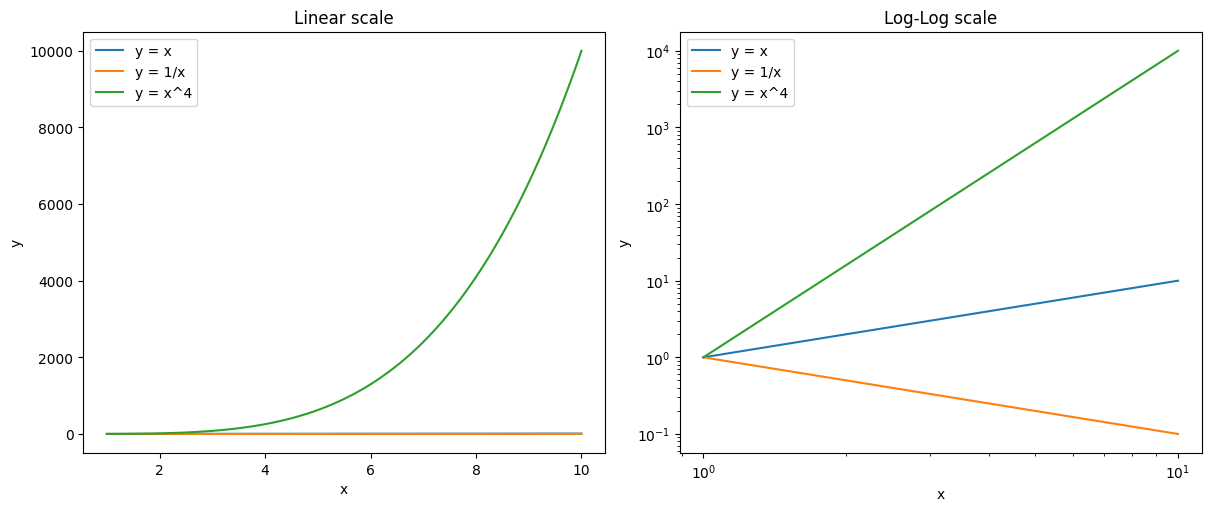

In [4]:
## ============================================================
## LOG-LOG SCALING
## ============================================================

## =========================
## Problem
## =========================
# Compare y = x, y = 1/x, y = x^4 on linear vs log-log scales.

## =========================
## Mathematical Idea
## =========================
# Power laws become linear in log-log scale:
# y = x^k → log(y) = k log(x)


## =========================
## Implementation
## =========================
x = np.linspace(1, 10, 100)

y1 = x
y2 = 1/x
y3 = x**4

fig, axs = plt.subplots(1,2, figsize=(12,5), layout="constrained")

# Linear scale
axs[0].plot(x, y1, label="y = x")
axs[0].plot(x, y2, label="y = 1/x")
axs[0].plot(x, y3, label="y = x^4")
axs[0].set_title("Linear scale")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].legend()

# Log-log scale
axs[1].loglog(x, y1, label="y = x")
axs[1].loglog(x, y2, label="y = 1/x")
axs[1].loglog(x, y3, label="y = x^4")
axs[1].set_title("Log-Log scale")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].legend()


## =========================
## Interpretation
## =========================
# On the log-log plot, the functions become straight lines.
# Their slopes match their exponents:
# y = x → slope 1
# y = 1/x → slope -1
# y = x^4 → slope 4


The value of S3 is: 0.75
The value of S6 is: 0.8571428571428572
The value of S10 is: 0.9090909090909091
The value of S20 is: 0.9523809523809522
The value of S100 is: 0.9900990099009898
In the linear equation log10(|sN-1|) = log10(a) + r*log10(1/N),
a = [0.9218164] and r = [0.99129454]


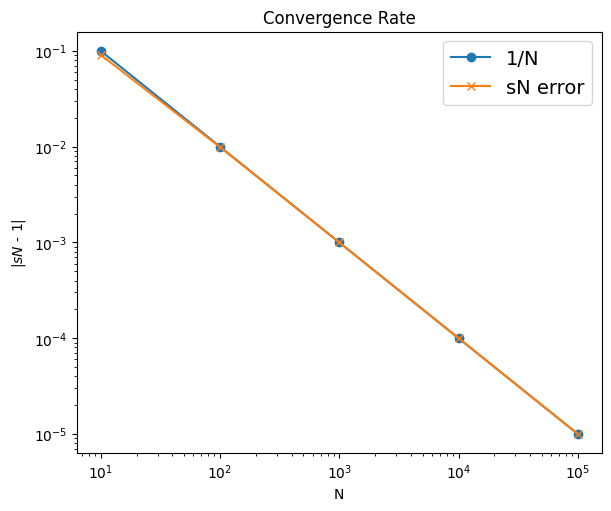

In [5]:
## ============================================================
## CONVERGENCE RATE ANALYSIS
## ============================================================

## =========================
## Problem
## =========================
# Estimate convergence rate of a series using least squares.

## =========================
## Mathematical Idea
## =========================
# If error behaves like:
# |s_N - L| ≈ a * (1/N)^r
#
# Then:
# log10(|s_N - L|) = log10(a) + r log10(1/N)


## =========================
## Implementation
## =========================

def f(x):  # start of function
    return 1/(x*(x+1))

def partialSum(f, n):  # start of function
    sum_ = 0
    for i in range(1, n+1):
        sum_ += f(i)
    return sum_


# Show convergence
sThree = partialSum(f, 3)
print(f"The value of S3 is: {sThree}")

sSix = partialSum(f, 6)
print(f"The value of S6 is: {sSix}")

sTen = partialSum(f, 10)
print(f"The value of S10 is: {sTen}")

sTwenty = partialSum(f, 20)
print(f"The value of S20 is: {sTwenty}")

sHundred = partialSum(f, 100)
print(f"The value of S100 is: {sHundred}")


## =========================
## Convergence Plot
## =========================
num_Ns = np.logspace(1,5,5,dtype=int)
error_list = []
invN = []

for N in num_Ns:
    sN = partialSum(f,N)
    error_list.append(abs(sN - 1.0))
    invN.append(1.0/N)

plt.figure(figsize=(6,5), layout="constrained")
plt.loglog(num_Ns, invN,"o-",label="1/N")
plt.loglog(num_Ns,error_list, "x-", label="sN error")
plt.legend(fontsize = 14)
plt.xlabel("N")
plt.ylabel("|$sN$ - 1|")
plt.title("Convergence Rate")


## =========================
## Linearization + Least Squares
## =========================
log_invN = np.log10(invN)
log_error_list = np.log10(error_list)

xlog = log_invN.T
slog = log_error_list.T

xcol = xlog[:,None]
scol = slog[:,None]

D = np.hstack([np.ones(xcol.shape), xcol])

DTD = np.matmul(D.T,D)
DTDinv = np.linalg.inv(DTD)
pInv= np.matmul(DTDinv,D.T)

Dbeta = np.matmul(pInv,scol)

alog,r = Dbeta
a = 10**alog

print(f"In the linear equation log10(|sN-1|) = log10(a) + r*log10(1/N),")
print(f"a = {a} and r = {r}")


## =========================
## Interpretation
## =========================
# The estimated convergence rate r ≈ 1
# This indicates first-order convergence:
# error decreases proportionally to 1/N